This is a sentimental analysis logistic regression model that can predict depression based on a user's words on social media. We used data from tweets to train the model. As developers, we were relatively new to the world of ML programming, so being able to train and test this model has been a great learning experience for us!

**Code Design:**

1. Getting data
2. Cleaning data   
3. Train test split of data
4. Model training
5. Model testing


**Library Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import re

**Uploading Data**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sentiment_tweets3.csv to sentiment_tweets3.csv


**Data Pre-Processing**

In [ ]:
# Reads the CSV file using pandas, removes duplicates and empty cells
import io
data = pd.read_csv(io.BytesIO(uploaded['sentiment_tweets3.csv']))
data = data.dropna(axis=0)
data = data.drop_duplicates()
data

,Index,message to examine,label (depression result)
0,106,just had a real good moment. i missssssssss hi...,0
1,217,is reading manga http://plurk.com/p/mzp1e,0
2,220,@comeagainjen http://twitpic.com/2y2lx - http:...,0
3,288,@lapcat Need to send 'em to my accountant tomo...,0
4,540,ADD ME ON MYSPACE!!! myspace.com/LookThunder,0
...,...,...,...
10309,802309,No Depression by G Herbo is my mood from now o...,1
10310,802310,What do you do when depression succumbs the br...,1
10311,802311,Ketamine Nasal Spray Shows Promise Against Dep...,1
10312,802312,dont mistake a bad day with depression! everyo...,1


In [ ]:
# converting to lowercase, removing URLs and punctuation through regular expressions
data['message to examine'] = data['message to examine'].apply(lambda x: re.split('(http:\/\/.*)|(https:\/\/.*)|(www\.\S+)|(\S+\.\S+/\S+)', str(x))[0])
data['message to examine'] = data['message to examine'].apply(lambda x: re.sub(r"[^\w\s]","",x))
data['message to examine'] = data['message to examine'].str.lower()
data

,Index,message to examine,label (depression result)
0,106,just had a real good moment i missssssssss him...,0
1,217,is reading manga,0
2,220,comeagainjen,0
3,288,lapcat need to send em to my accountant tomorr...,0
4,540,add me on myspace,0
...,...,...,...
10309,802309,no depression by g herbo is my mood from now o...,1
10310,802310,what do you do when depression succumbs the br...,1
10311,802311,ketamine nasal spray shows promise against dep...,1
10312,802312,dont mistake a bad day with depression everyon...,1


In [ ]:
# Removes stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def removeStopwords(text):
  return " ".join([word for word in text.split() if word not in stop_words])

data['message to examine'] = data['message to examine'].apply(removeStopwords)
data

,Index,message to examine,label (depression result)
0,106,real good moment missssssssss much,0
1,217,reading manga,0
2,220,comeagainjen,0
3,288,lapcat need send em accountant tomorrow oddly ...,0
4,540,add myspace,0
...,...,...,...
10309,802309,depression g herbo mood im done stressing peop...,1
10310,802310,depression succumbs brain makes feel like youl...,1
10311,802311,ketamine nasal spray shows promise depression ...,1
10312,802312,dont mistake bad day depression everyone em,1


**Vectorization**

TF-IDF (Term Frequency - Inverse Document Frequency) Vectorization is the technique we used to convert our words into numbers to train the model. Basically, it looks at every single word in the entire dataset, finds how many times each word appears in a Tweet, and compares that with how many times the word appears in the rest of the dataset. This helps us train the model by using numbers to show what words often appear in tweets where a user could potentially have depression.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
corpus = data['message to examine'].tolist()

vectorizer.fit(corpus)


TfidfVectorizer()

In [ ]:
txt = vectorizer.transform(data['message to examine']).toarray()
print(len(txt))

10314


Vectorization - another approach

In [ ]:
tfidfvectorizer = TfidfVectorizer(analyzer='word', stop_words= 'english')

tfidf_wm = tfidfvectorizer.fit_transform(data["message to examine"])

#tfidf_tokens = tfidfvectorizer.get_feature_names()

df_tfidfvect = pd.DataFrame(data = tfidf_wm.toarray())
df_tfidfvect


,0,1,2,3,4,5,6,7,8,9,...,21609,21610,21611,21612,21613,21614,21615,21616,21617,21618
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10309,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10312,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Splitting Dataset into Training and Test Data**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(txt,data['label (depression result)'],test_size = 0.2)

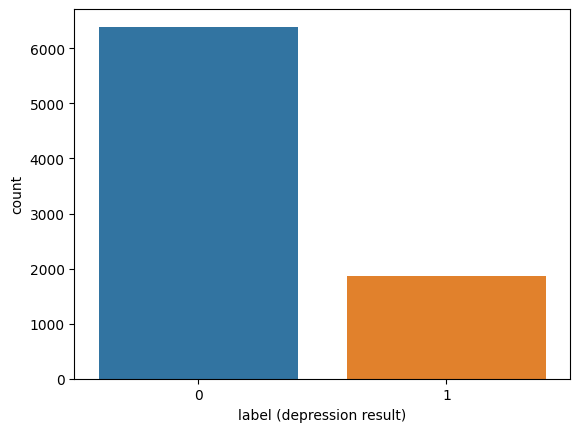

In [ ]:
sns.countplot(x=y_train)
plt.show()

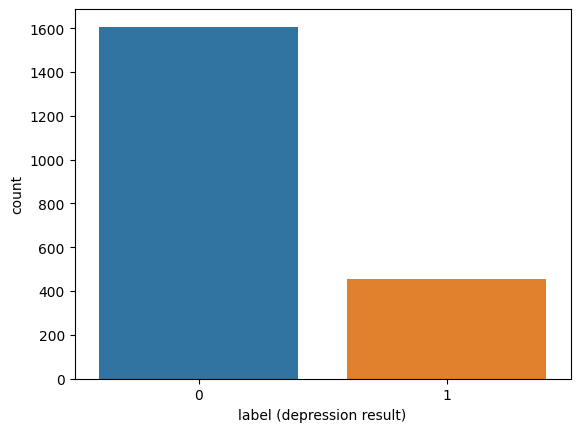

In [ ]:
sns.countplot(x=y_test)
plt.show()

**Fitting the Model**

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

**Testing the Model**

In [ ]:
lr.predict(X_test)

array([0, 1, 1, ..., 0, 0, 0])

In [ ]:
print(y_test)

7366     0
10116    1
9013     1
8200     1
8032     1
        ..
9597     1
1782     0
4884     0
6371     0
9563     1
Name: label (depression result), Length: 2063, dtype: int64


In [ ]:
from sklearn.metrics import classification_report
y_pred = lr.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1607
           1       1.00      0.88      0.94       456

    accuracy                           0.97      2063
   macro avg       0.98      0.94      0.96      2063
weighted avg       0.97      0.97      0.97      2063



**Sources**


*   https://medium.com/@cmukesh8688/tf-idf-vectorizer-scikit-learn-dbc0244a911a
*   Various Tutorials on https://www.kaggle.com/datasets/gargmanas/sentimental-analysis-for-tweets/code
*   https://www.statology.org/sklearn-classification-report/




